# Практическая 2 (Саттаров Булат Рамилевич ЭФМО-01-25)

## Задание
Загрузите файл winequality-red.csv (с помощью pd.read_csv).

Последний столбец отвечает за качество вина. Будем считать, что хорошее вино начинается с цифры 7 и выше. 
Остальное вино будем счиатать некачественным.

Сделайте классификацию вина по данному датасету. Два класса "Хорошее" и "Не качественное". 
Результатом будем считать уравнение гиперповерхности на гиперпространстве параметров, отделяющее один класс от другого. 

In [62]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Загрузка выборки

In [63]:
from pathlib import Path

csv_path = Path('winequality-red.csv')

try:
    wine_dataset = pd.read_csv(csv_path, sep=';')
    if wine_dataset.shape[1] == 1:
        wine_dataset = pd.read_csv(csv_path)
except Exception:
    wine_dataset = pd.read_csv(csv_path)

wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Множество объектов
В данной задаче множество объектов описывается $n=11$ признаками:
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol

In [64]:
print('Размер выборки составляет l={} объектов.'.format(len(wine_dataset)))

Размер выборки составляет l=1599 объектов.


In [65]:
analysis_dataset = wine_dataset.copy()
analysis_dataset['класс'] = np.where(analysis_dataset['quality'] >= 7, 'Хорошее', 'Не качественное')

analysis_dataset['класс'].value_counts()

класс
Не качественное    1382
Хорошее             217
Name: count, dtype: int64

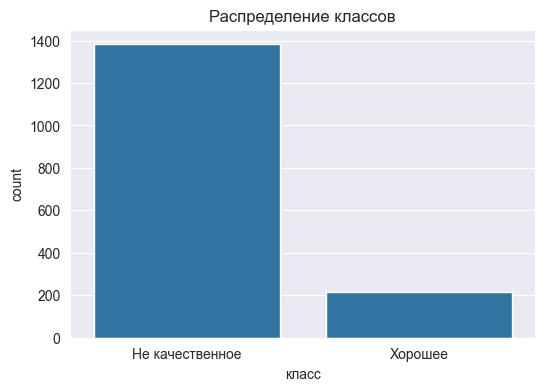

In [66]:
plt.figure(figsize=(6, 4))
sns.countplot(data=analysis_dataset, x='класс')
plt.title('Распределение классов')
plt.show()

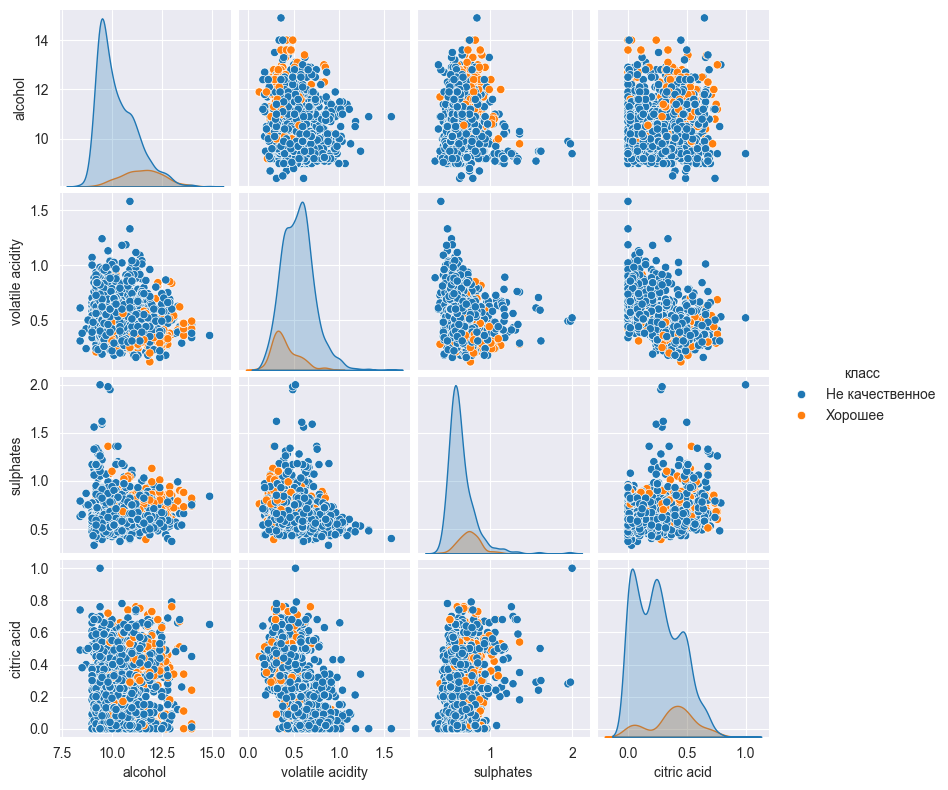

In [67]:
plot_columns = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'класс']
sns.pairplot(analysis_dataset[plot_columns], hue='класс', height=2)
plt.show()

Из графиков видно, что классы пересекаются, но по ряду признаков наблюдается различие. 
Например, хорошие вина в среднем чаще имеют более высокий `alcohol` и `sulphates`, а также более низкий `volatile acidity`. 
Полного линейного разделения на всех проекциях нет, поэтому задача не является совсем простой, но логистическая регрессия может построить разделяющую гиперплоскость в пространстве признаков.

## Построение модели
### Преобразование данных

Преобразуем исходную задачу к бинарной классификации. 
Классы закодируем целыми числами $-1$ и $1$:
* `Не качественное` $\to -1$
* `Хорошее` $\to 1$

In [68]:
binary_dataset = wine_dataset.copy()
binary_dataset['класс'] = np.where(binary_dataset['quality'] >= 7, 1, -1)
binary_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,класс
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,-1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,-1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,-1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,-1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,-1


In [69]:
X = binary_dataset.drop(columns=['quality', 'класс']).values
y = binary_dataset['класс'].values.reshape(-1)
X = np.array(np.hstack([X, np.ones([len(X), 1])]), dtype=np.float64)
y = np.array(y, dtype=np.int64)

X.shape, y.shape

((1599, 12), (1599,))

In [70]:
model = LogisticRegression(random_state=0, max_iter=5000, fit_intercept=False)
_ = model.fit(X, y)

# Вектор оптимальных параметров

In [71]:
model.coef_

array([[-0.06335039, -2.77554041,  0.24681499,  0.10262266, -1.58158146,
         0.01390926, -0.01722415, -1.43621234, -2.53131255,  2.15950301,
         0.92392583, -1.42567304]])